/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_2436/2736470283.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores.values()), y=list(scores.keys()), palette='viridis', ax=ax[0])
/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_2436/2736470283.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma', ax=ax[1])


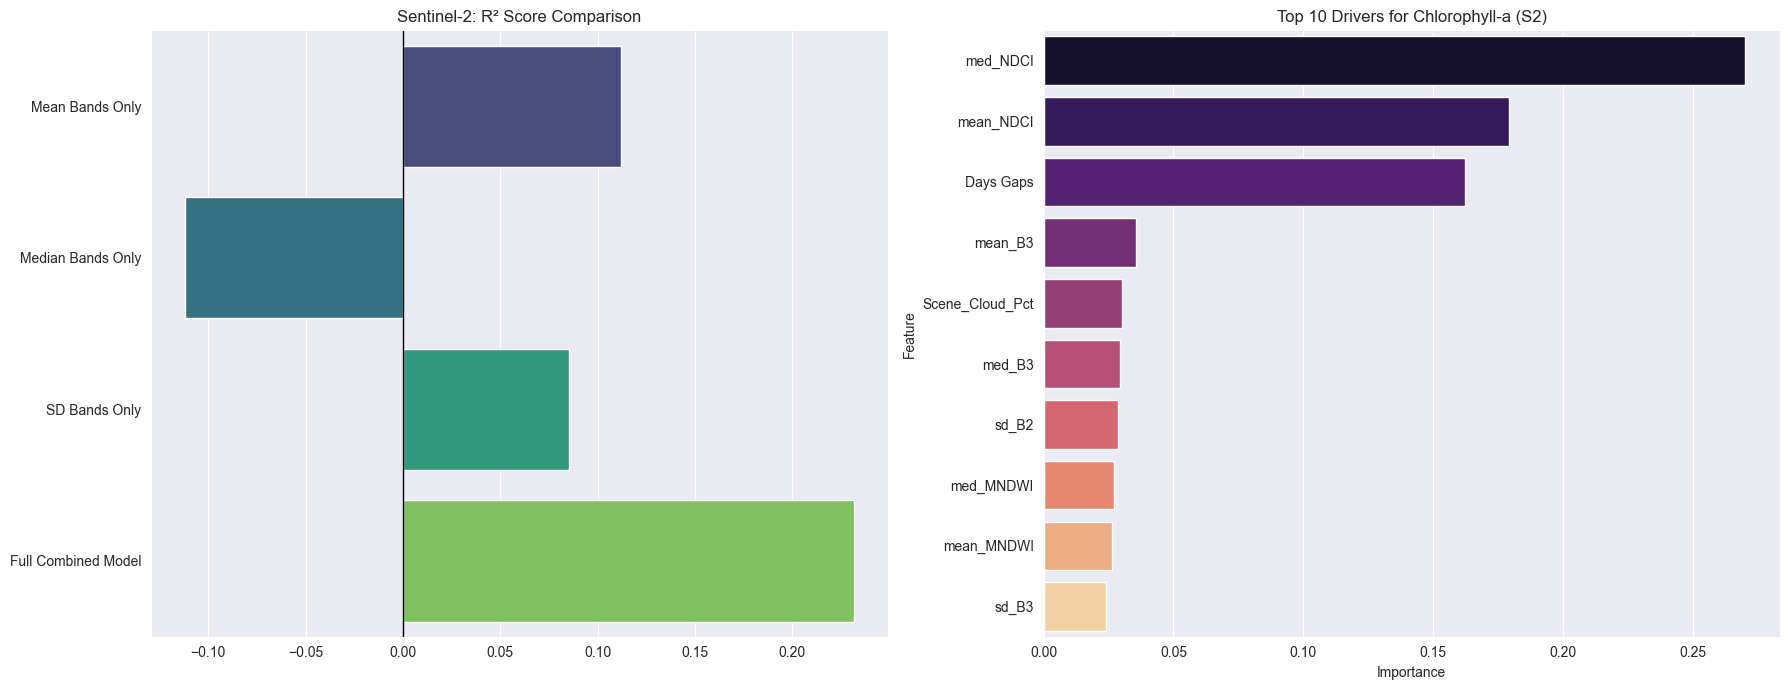

Final Model R2: 0.2319


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load S2 data
df_s2 = pd.read_csv('Tappan_S2_Bands_NDCI_MNDWI_30mBuffer.csv')
target_col = 'Target Variable(Chlorophyll-a)'

# 2. Define Groups
mean_cols = [c for c in df_s2.columns if 'mean_B' in c]
med_cols = [c for c in df_s2.columns if 'med_B' in c and 'NDCI' not in c and 'MNDWI' not in c]
sd_cols = [c for c in df_s2.columns if 'sd_B' in c]
extra_cols = ['mean_NDCI', 'med_NDCI', 'mean_MNDWI', 'med_MNDWI', 'Days Gaps', 'Scene_Cloud_Pct']

def get_scores(feature_list):
    data = df_s2[[target_col] + feature_list].dropna()
    X = data[feature_list]
    y = data[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    return r2_score(y_test, rf.predict(X_test)), rf

# 3. Compare Models
scores = {
    "Mean Bands Only": get_scores(mean_cols)[0],
    "Median Bands Only": get_scores(med_cols)[0],
    "SD Bands Only": get_scores(sd_cols)[0],
    "Full Combined Model": get_scores(mean_cols + med_cols + sd_cols + extra_cols)[0]
}

# 4. Final Model & Importance
final_r2, final_model = get_scores(mean_cols + med_cols + sd_cols + extra_cols)
importance_df = pd.DataFrame({
    'Feature': mean_cols + med_cols + sd_cols + extra_cols,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# --- Visualizations ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Comparison Bar Chart
sns.barplot(x=list(scores.values()), y=list(scores.keys()), palette='viridis', ax=ax[0])
ax[0].set_title('Sentinel-2: R² Score Comparison')
ax[0].axvline(0, color='black', lw=1)

# Feature Importance
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma', ax=ax[1])
ax[1].set_title('Top 10 Drivers for Chlorophyll-a (S2)')

plt.tight_layout()
plt.show()

print(f"Final Model R2: {final_r2:.4f}")